# Import Model

In [ ]:
!pip install nlp-id
import pandas as pd
import numpy as np
import pickle
import nltk
from nlp_id.postag import PosTag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score, cross_validate, cross_val_predict
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from google.colab import drive
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import gdown
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 15.3 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=3e184b7e2593ebab8b87135a0da2b548ee1b1edf416b5a8da06cae5bbcdda376
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalled huggingface-hub-0.36.0


# Load Data

In [ ]:
drive_url = 'https://drive.google.com/uc?id=1oxW4cFsLranfgs8ZfPVYNUSm863i0GGu'
output_filename = 'data.xlsx'
gdown.download(drive_url, output_filename, quiet=False)

try:
    df = pd.read_excel(output_filename)
    print(df.head())
except Exception as e:
    print(f"Error to load file: {e}")

Downloading...
From: https://drive.google.com/uc?id=1oxW4cFsLranfgs8ZfPVYNUSm863i0GGu
To: /content/data.xlsx
100%|██████████| 9.36M/9.36M [00:00<00:00, 41.1MB/s]


                                               title    source  \
0  Hoaks! Prabowo nyatakan Indonesia siap perang ...    ANTARA   
1  Hoaks! Akun TikTok Kementerian Agama tawarkan ...    ANTARA   
2  Cuaca Sepekan ke Depan, BMKG Minta Aceh dan Su...  tempo.co   
3  Cek fakta, Pramono sebut hanya 44 persen warga...    ANTARA   
4  Hoaks! Video harimau terbawa arus banjir Sibol...    ANTARA   

               date    category  \
0   27 Agustus 2025       Dunia   
1   22 Oktober 2025   Humaniora   
2   2 Desember 2025  Lingkungan   
3  21 November 2024       Metro   
4   1 Desember 2025  Warta Bumi   

                                              narasi  \
0  Jakarta (ANTARA/JACX) – Sebuah unggahan video ...   
1  Jakarta (ANTARA/JACX) – Sebuahakun TikTokmenga...   
2  SETELAH beberapa hari terakhir ini benar-benar...   
3  Jakarta (ANTARA/JACX) – Calon Gubernur (Cagub)...   
4  Jakarta (ANTARA/JACX) – Sebuah unggahanTikTokb...   

                                          penjelasan ke

# DATA DESCRIPTION

In [ ]:
print("Jumlah data:", len(df))
print(df['label'].value_counts())
print(df.head())

Jumlah data: 5527
label
0    3416
1    2111
Name: count, dtype: int64
                                               title    source  \
0  Hoaks! Prabowo nyatakan Indonesia siap perang ...    ANTARA   
1  Hoaks! Akun TikTok Kementerian Agama tawarkan ...    ANTARA   
2  Cuaca Sepekan ke Depan, BMKG Minta Aceh dan Su...  tempo.co   
3  Cek fakta, Pramono sebut hanya 44 persen warga...    ANTARA   
4  Hoaks! Video harimau terbawa arus banjir Sibol...    ANTARA   

               date    category  \
0   27 Agustus 2025       Dunia   
1   22 Oktober 2025   Humaniora   
2   2 Desember 2025  Lingkungan   
3  21 November 2024       Metro   
4   1 Desember 2025  Warta Bumi   

                                              narasi  \
0  Jakarta (ANTARA/JACX) – Sebuah unggahan video ...   
1  Jakarta (ANTARA/JACX) – Sebuahakun TikTokmenga...   
2  SETELAH beberapa hari terakhir ini benar-benar...   
3  Jakarta (ANTARA/JACX) – Calon Gubernur (Cagub)...   
4  Jakarta (ANTARA/JACX) – Sebuah unggahan

In [ ]:
# print("Jumlah data kosong per kolom:")
# print(df.isnull().sum())

In [ ]:
X = df['clean_narasi']
y = df['label']

print(f"Total data awal: {len(df)}")
print(f"Sebaran label awal:\n{y.value_counts()}")



Total data awal: 5527
Sebaran label awal:
label
0    3416
1    2111
Name: count, dtype: int64


# SPLIT DATA

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# FEATURE EXTRACTION

In [ ]:
nltk.download('punkt_tab')

postagger = PosTag()
forbidden_tags = {'NN', 'NP', 'NNP'}
CUSTOM_WORDS_TO_REMOVE = {
    'jokowi', 'gibran', 'rakabuming', 'mulyani', 'sri', 'tni',
    'oktober', 'maharani', 'megawati', 'menkeu',
    'jakarta', 'prabowo', 'presiden', 'purbaya',
    'indonesia', 'facebook', 'sumatera',
    "tidak", "bukan", "belum", "tanpa" # hapus unigram negasi
}

def is_only_nouns(ngram_text):
    tags = postagger.get_pos_tag(ngram_text)
    # return all(
    #     (tag in forbidden_tags) or (word.lower() in CUSTOM_WORDS_TO_REMOVE)
    #     for word, tag in tags
    # )
    return all(word.lower() in CUSTOM_WORDS_TO_REMOVE for word, tag in tags)

# buat initial vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,  # 5000 kata terpenting
    ngram_range=(1,3),  # unigrams + bigrams
    stop_words=None
)
tfidf.fit(X)

# ambil fitur (unigrams and bigrams)
all_features = tfidf.get_feature_names_out()

# filter n-grams yang hanya nouns
filtered_vocabulary = [
    feat for feat in all_features if not is_only_nouns(feat)
]

# inisialisasi ulang vectorizernya menggunakan filtered vocab
final_tfidf = TfidfVectorizer(vocabulary=filtered_vocabulary)
X_train_tfidf = final_tfidf.fit_transform(X_train)
X_test_tfidf = final_tfidf.transform(X_test)

removed_nouns = sorted(list(set(all_features) - set(filtered_vocabulary)))

print(f"Original vocabulary size: {len(all_features)}")
print(f"Filtered vocabulary size: {len(filtered_vocabulary)}")
print(f"Number of N-grams removed (only nouns): {len(removed_nouns)}")
print("Removed N-grams (only nouns):")
for noun in removed_nouns:
    print(f"- {noun}")

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(final_tfidf, f)

print("TF-IDF Vectorizer saved as tfidf_vectorizer.pkl")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


postagger_v10.pkl:   0%|          | 0.00/282M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DictVectorizer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.6.1. This might lead to b

Original vocabulary size: 5000
Filtered vocabulary size: 4968
Number of N-grams removed (only nouns): 32
Removed N-grams (only nouns):
- belum
- bukan
- facebook
- facebook oktober
- gibran
- gibran rakabuming
- indonesia
- indonesia tidak
- jakarta
- jokowi
- maharani
- megawati
- menkeu
- menkeu purbaya
- mulyani
- oktober
- prabowo
- presiden
- presiden gibran
- presiden gibran rakabuming
- presiden indonesia
- presiden jakarta
- presiden jokowi
- presiden prabowo
- purbaya
- rakabuming
- sri
- sri mulyani
- sumatera
- tanpa
- tidak
- tni
TF-IDF Vectorizer saved as tfidf_vectorizer.pkl


In [ ]:
# tfidf_vectorizer = TfidfVectorizer(
#     max_features=5000,  # 5000 kata terpenting
#     ngram_range=(1,2),  # unigrams + bigrams
#     stop_words=None
# )

# # Fit & transform data training
# X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
# X_test_tfidf = tfidf_vectorizer.transform(X_test)

# # Save TF-IDF vectorizer untuk dipakai Streamlit
# with open("tfidf_vectorizer.pkl", "wb") as f:
#     pickle.dump(tfidf_vectorizer, f)

# print("TF-IDF Vectorizer saved as tfidf_vectorizer.pkl")

## VISUALISASI DISTRIBUSI

In [ ]:
# text_hoaks = " ".join(df[df['status']=='hoax']['clean_narasi'])
# wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_hoaks)

# plt.figure(figsize=(15,7))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')
# plt.title("WordCloud Kata-kata Hoaks")
# plt.show()


In [ ]:
# text_fact = " ".join(df[df['status']=='fact']['clean_narasi'])
# wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_fact)

# plt.figure(figsize=(15,7))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')
# plt.title("WordCloud Kata-kata Fakta")
# plt.show()


In [ ]:
def get_tfidf_frequencies(tfidf_matrix, vectorizer):
    """
    Menghitung rata-rata skor TF-IDF untuk setiap fitur (Unigram/N-gram)
    dan mengembalikannya dalam bentuk dictionary.
    """
    tfidf_means = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    feature_names = vectorizer.get_feature_names_out()

    return {feature_names[i]: tfidf_means[i] * 1000 for i in range(len(feature_names))}

# ambil baris untuk masing-masing kelas
hoax_indices = np.where(y_train == 1)[0]
real_indices = np.where(y_train == 0)[0]

# slice matriks TF-IDF berdasarkan kelas
X_tfidf_hoax = X_train_tfidf[hoax_indices]
X_tfidf_real = X_train_tfidf[real_indices]

# hitung frekuensi berdasarkan skor TF-IDF
hoax_freqs = get_tfidf_frequencies(X_tfidf_hoax, final_tfidf)
real_freqs = get_tfidf_frequencies(X_tfidf_real, final_tfidf)



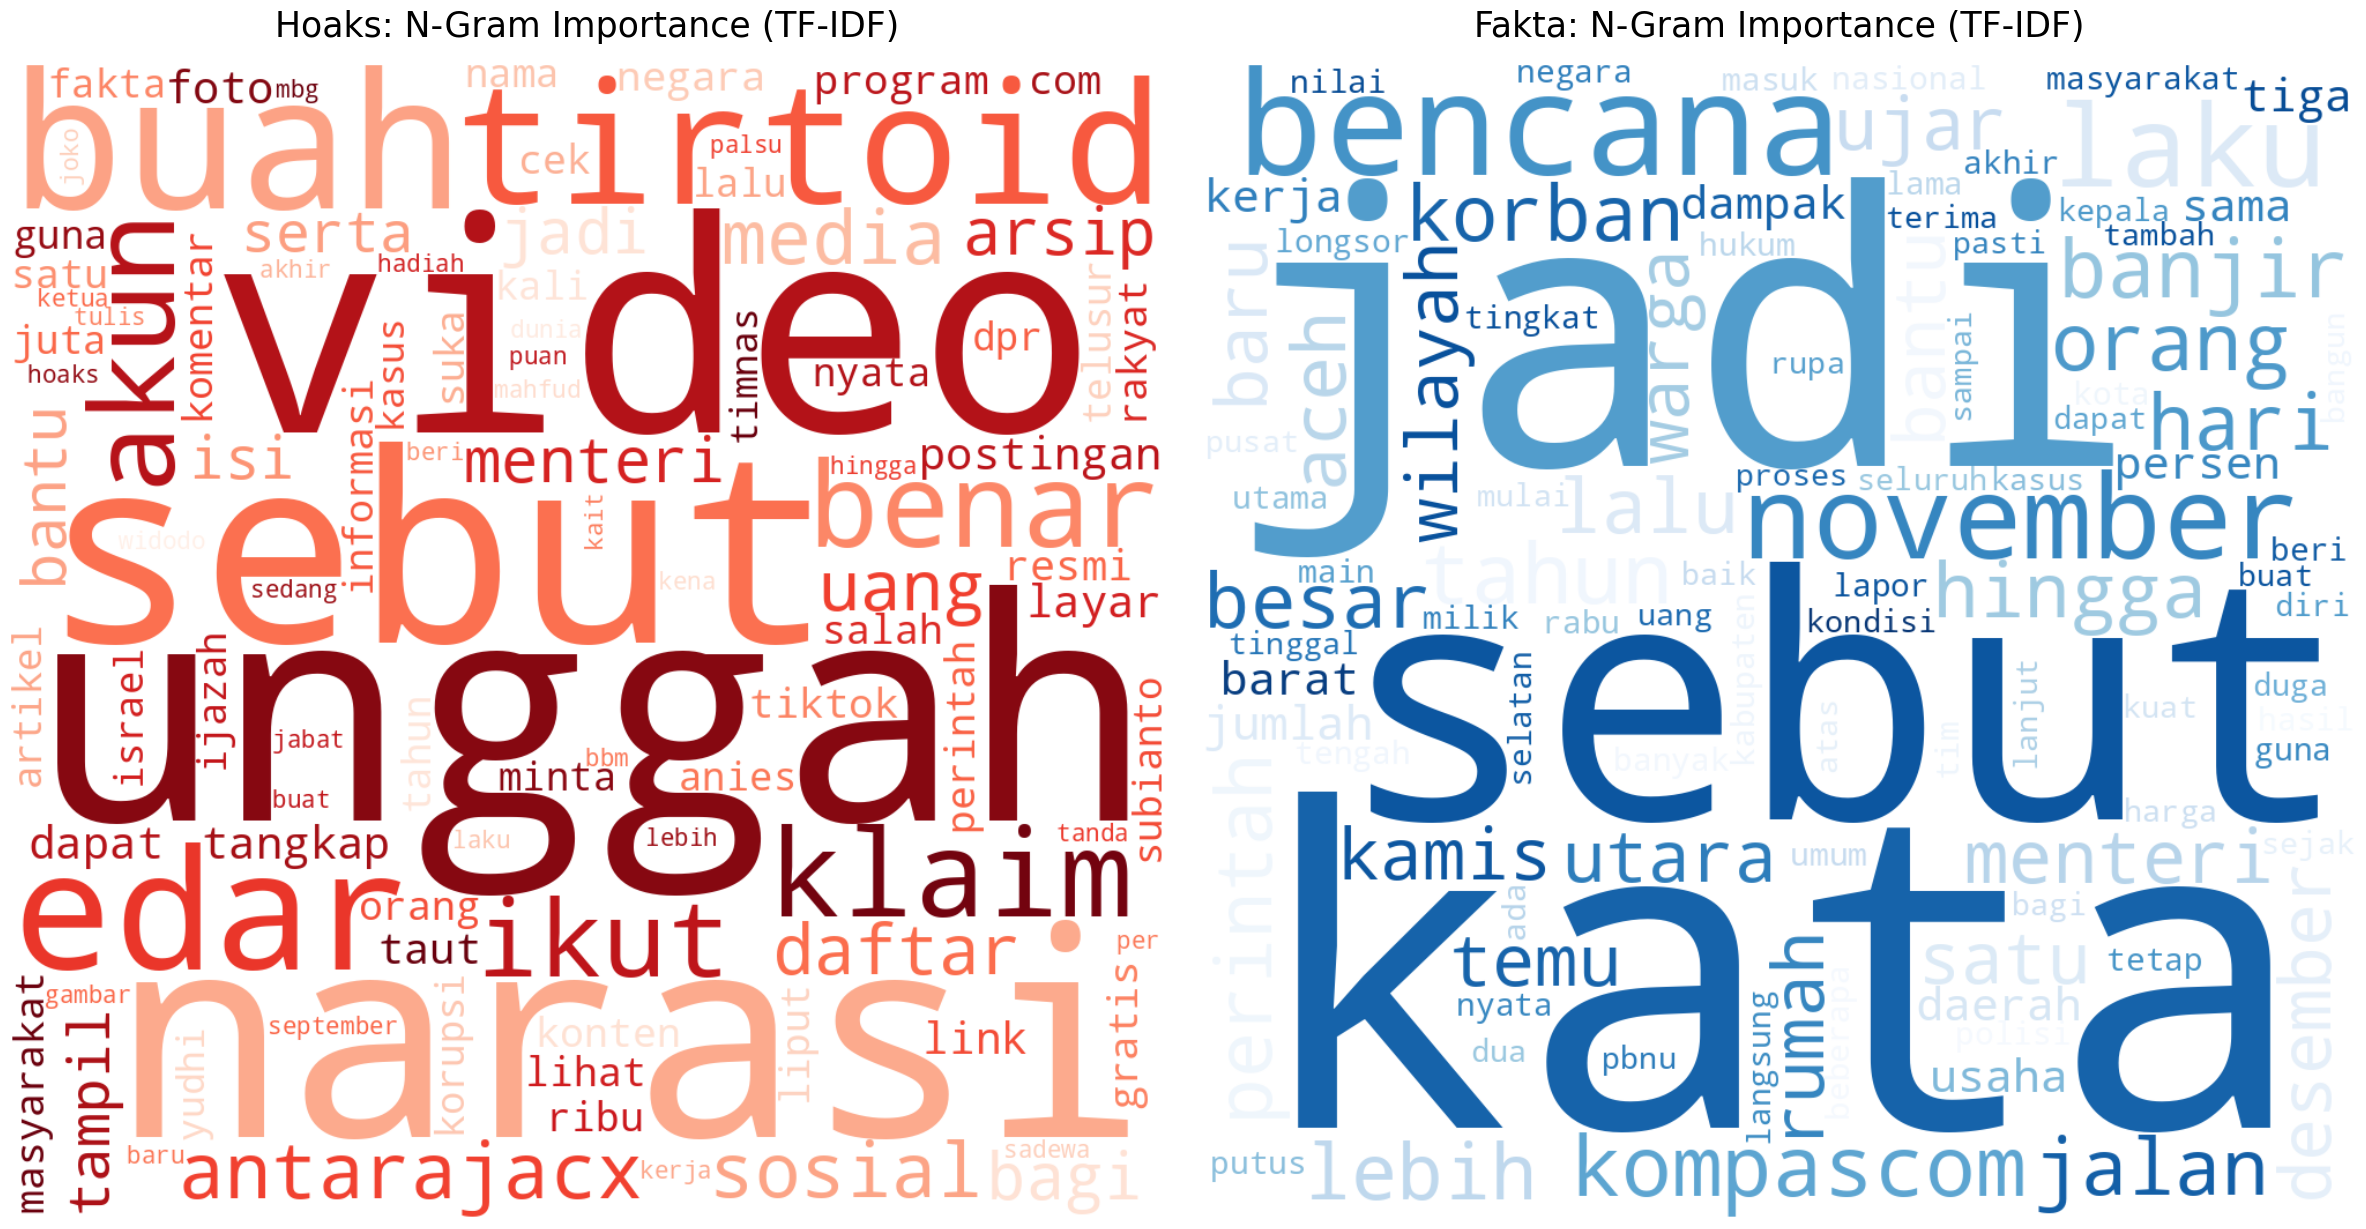

In [ ]:
# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

# WordCloud Hoaks (N-Gram + TF-IDF)
wc_hoax = WordCloud(
    width=1000, height=1000,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate_from_frequencies(hoax_freqs)

ax1.imshow(wc_hoax, interpolation='bilinear')
ax1.set_title("Hoaks: N-Gram Importance (TF-IDF)", fontsize=25, pad=20)
ax1.axis('off')

# WordCloud Fakta (N-Gram + TF-IDF)
wc_real = WordCloud(
    width=1000, height=1000,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate_from_frequencies(real_freqs)

ax2.imshow(wc_real, interpolation='bilinear')
ax2.set_title("Fakta: N-Gram Importance (TF-IDF)", fontsize=25, pad=20)
ax2.axis('off')


plt.tight_layout()
plt.show()

# HANDLING IMBALANCE (SMOTE)

In [ ]:
print("Distribusi label sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

print("Distribusi label setelah SMOTE:")
print(pd.Series(y_train_res).value_counts())

with open("train_smote.pkl", "wb") as f:
    pickle.dump((X_train_res, y_train_res), f)

Distribusi label sebelum SMOTE:
label
0    2732
1    1689
Name: count, dtype: int64
Distribusi label setelah SMOTE:
label
0    2732
1    2732
Name: count, dtype: int64


# Validation K-Fold Object

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

# TRAIN MODEL (NAIVE BAYES)

In [ ]:
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0],
    'fit_prior': [True, False]
}

nb_model = MultinomialNB()
grid_search = GridSearchCV(estimator=nb_model, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

print("Starting Hyperparameter Tuning...")
grid_search.fit(X_train_res, y_train_res)

# Get the best model from grid search
best_nb_model = grid_search.best_estimator_

print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best CV Accuracy during tuning: {grid_search.best_score_:.4f}")

# Evaluate the best model (cross validation)
cv_results_nb = cross_validate(best_nb_model, X_train_res, y_train_res, cv=kf, scoring=scoring_metrics)

print(f"Average Accuracy: {cv_results_nb['test_accuracy'].mean():.4f}")
print(f"Average Precision: {cv_results_nb['test_precision'].mean():.4f}")
print(f"Average Recall: {cv_results_nb['test_recall'].mean():.4f}")
print(f"Average F1-Score: {cv_results_nb['test_f1'].mean():.4f}")


y_pred_cv_nb = cross_val_predict(best_nb_model, X_train_res, y_train_res, cv=kf)
cm_cv_nb = confusion_matrix(y_train_res, y_pred_cv_nb)

# Save model
best_nb_model.fit(X_train_res, y_train_res)
with open("model_nb_tuned.pkl", "wb") as f:
    pickle.dump(nb_model, f)

print("Tuned Naive Bayes model saved")


Starting Hyperparameter Tuning...
Fitting 10 folds for each of 14 candidates, totalling 140 fits

Best Parameters found: {'alpha': 0.5, 'fit_prior': True}
Best CV Accuracy during tuning: 0.9857
Average Accuracy: 0.9857
Average Precision: 0.9836
Average Recall: 0.9880
Average F1-Score: 0.9858
Tuned Naive Bayes model saved


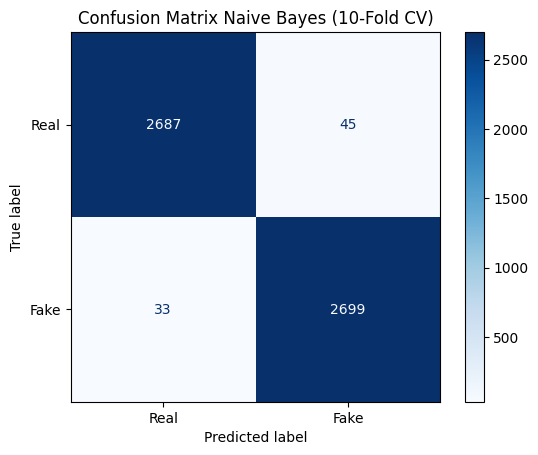

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cv_nb, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix Naive Bayes (10-Fold CV)")
plt.show()

In [ ]:
# nb_model = MultinomialNB()

# cv_results_nb = cross_validate(nb_model, X_train_res, y_train_res, cv=kf, scoring=scoring_metrics)

# print(f"Average Accuracy: {cv_results_nb['test_accuracy'].mean():.4f}")
# print(f"Average Precision: {cv_results_nb['test_precision'].mean():.4f}")
# print(f"Average Recall: {cv_results_nb['test_recall'].mean():.4f}")
# print(f"Average F1-Score: {cv_results_nb['test_f1'].mean():.4f}")


# y_pred_cv_nb = cross_val_predict(nb_model, X_train_res, y_train_res, cv=kf)
# cm_cv_nb = confusion_matrix(y_train_res, y_pred_cv_nb)

# # 4. Save and Finalize
# nb_model.fit(X_train_res, y_train_res)
# with open("model_nb.pkl", "wb") as f:
#   pickle.dump(nb_model, f)

# print("Naive Bayes model saved as model_nb.pkl")


# # 5. Optional: Plot the matrix (Useful for your Streamlit Visualizations)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_cv_nb, display_labels=['Real', 'Fake'])
# disp.plot(cmap='Blues')
# plt.title("Confusion Matrix Naive Bayes (10-Fold CV)")
# plt.show()

In [ ]:
# y_pred_nb = nb_model.predict(X_test_tfidf)

# acc_nb = accuracy_score(y_test, y_pred_nb)
# prec_nb = precision_score(y_test, y_pred_nb)
# rec_nb = recall_score(y_test, y_pred_nb)
# f1_nb = f1_score(y_test, y_pred_nb)

# print("\n=== Baseline Naive Bayes Evaluation ===")
# print("Accuracy :", acc_nb)
# print("Precision:", prec_nb)
# print("Recall   :", rec_nb)
# print("F1-Score :", f1_nb)
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_nb))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_nb))

## Evaluation with Unseen Data

In [ ]:
y_pred_nb = best_nb_model.predict(X_test_tfidf)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("\n=== Baseline Naive Bayes Evaluation ===")
print("Accuracy :", acc_nb)
print("Precision:", prec_nb)
print("Recall   :", rec_nb)
print("F1-Score :", f1_nb)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


=== Baseline Naive Bayes Evaluation ===
Accuracy : 0.9801084990958409
Precision: 0.9739336492890995
Recall   : 0.9739336492890995
F1-Score : 0.9739336492890995

Confusion Matrix:
[[673  11]
 [ 11 411]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       684
           1       0.97      0.97      0.97       422

    accuracy                           0.98      1106
   macro avg       0.98      0.98      0.98      1106
weighted avg       0.98      0.98      0.98      1106



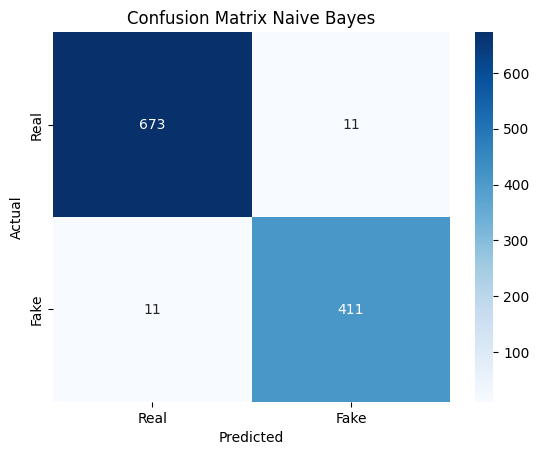

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Naive Bayes")
plt.show()

# TRAIN MODEL (Logistic Regression)

Running Hyperparameter Tuning...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'C': 30, 'max_iter': 1000, 'solver': 'liblinear'}
Average Accuracy: 0.9973
Average Precision: 0.9967
Average Recall: 0.9978
Average F1-Score: 0.9972
Logistic Regression model saved as model_lg.pkl


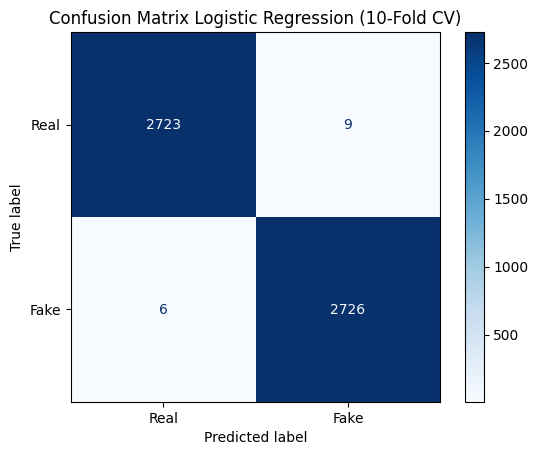

In [ ]:
param_grid_lg = {
    'C': [1, 10, 20, 30, 40, 50],  # inverse of regularization strength, higher number means penalty for complex coefficient is weaker
    'solver': ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"], # Algorithms to use in the optimization problem
    'max_iter': [1000]
}

lg_model = LogisticRegression(random_state=42)

random_search_lg = GridSearchCV(
    estimator=lg_model,
    param_grid=param_grid_lg,
    cv=5,
    verbose=2,
    n_jobs=-1
)

print("Running Hyperparameter Tuning...")
random_search_lg.fit(X_train_res, y_train_res)

best_lg_model = random_search_lg.best_estimator_
print("Best parameters:", random_search_lg.best_params_)

cv_results_lg = cross_validate(best_lg_model, X_train_res, y_train_res, cv=kf, scoring=scoring_metrics)

print(f"Average Accuracy: {cv_results_lg['test_accuracy'].mean():.4f}")
print(f"Average Precision: {cv_results_lg['test_precision'].mean():.4f}")
print(f"Average Recall: {cv_results_lg['test_recall'].mean():.4f}")
print(f"Average F1-Score: {cv_results_lg['test_f1'].mean():.4f}")


y_pred_cv_lg = cross_val_predict(best_lg_model, X_train_res, y_train_res, cv=kf)
cm_cv_lg = confusion_matrix(y_train_res, y_pred_cv_lg)

# 4. Save and Finalize
best_lg_model.fit(X_train_res, y_train_res)
with open("model_lg.pkl", "wb") as f:
    pickle.dump(best_lg_model, f)

print("Logistic Regression model saved as model_lg.pkl")

# 5. Optional: Plot the matrix (Useful for your Streamlit Visualizations)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cv_lg, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix Logistic Regression (10-Fold CV)")
plt.show()


## Evaluation with Unseen Data

In [ ]:
y_pred_lg = best_lg_model.predict(X_test_tfidf)

acc_lg = accuracy_score(y_test, y_pred_lg)
prec_lg = precision_score(y_test, y_pred_lg)
rec_lg = recall_score(y_test, y_pred_lg)
f1_lg = f1_score(y_test, y_pred_lg)

print("\n=== Baseline Logistic Regression Evaluation ===")
print("Accuracy :", acc_lg)
print("Precision:", prec_lg)
print("Recall   :", rec_lg)
print("F1-Score :", f1_lg)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lg))


=== Baseline Logistic Regression Evaluation ===
Accuracy : 0.9963833634719711
Precision: 0.995260663507109
Recall   : 0.995260663507109
F1-Score : 0.995260663507109

Confusion Matrix:
[[682   2]
 [  2 420]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       684
           1       1.00      1.00      1.00       422

    accuracy                           1.00      1106
   macro avg       1.00      1.00      1.00      1106
weighted avg       1.00      1.00      1.00      1106



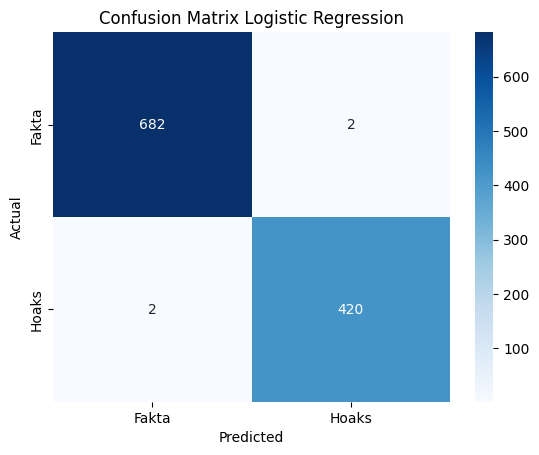

In [ ]:
cm_lg = confusion_matrix(y_test, y_pred_lg)

sns.heatmap(cm_lg, annot=True, fmt='d', cmap='Blues', xticklabels=['Fakta','Hoaks'], yticklabels=['Fakta','Hoaks'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Logistic Regression")
plt.show()

# TRAIN MODEL (Decision Tree)

Running Hyperparameter Tuning...
Fitting 5 folds for each of 189 candidates, totalling 945 fits
Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Average Accuracy: 0.9888
Average Precision: 0.9882
Average Recall: 0.9893
Average F1-Score: 0.9887
Logistic Regression model saved as model_dt.pkl


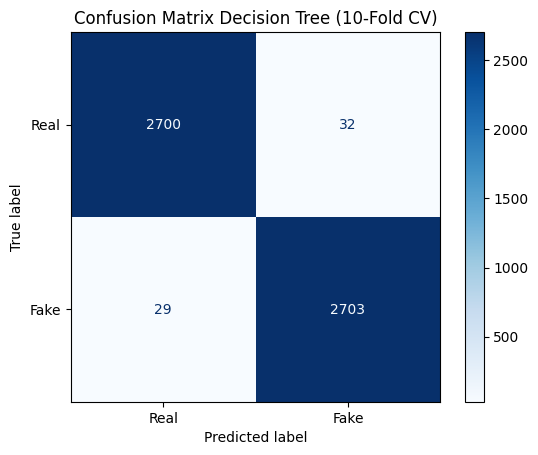

In [ ]:
param_grid_dt = {
    'max_depth': [None, 10, 15, 20, 25, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy', 'log_loss']
}

dt_model = DecisionTreeClassifier(random_state=42)

random_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    verbose=2,
    n_jobs=-1
)

print("Running Hyperparameter Tuning...")
random_search_dt.fit(X_train_res, y_train_res)

best_dt_model = random_search_dt.best_estimator_
print("Best parameters:", random_search_dt.best_params_)

cv_results_dt = cross_validate(best_dt_model, X_train_res, y_train_res, cv=kf, scoring=scoring_metrics)

print(f"Average Accuracy: {cv_results_dt['test_accuracy'].mean():.4f}")
print(f"Average Precision: {cv_results_dt['test_precision'].mean():.4f}")
print(f"Average Recall: {cv_results_dt['test_recall'].mean():.4f}")
print(f"Average F1-Score: {cv_results_dt['test_f1'].mean():.4f}")


y_pred_cv_dt = cross_val_predict(best_dt_model, X_train_res, y_train_res, cv=kf)
cm_cv_dt = confusion_matrix(y_train_res, y_pred_cv_dt)


# 4. Save and Finalize
best_dt_model.fit(X_train_res, y_train_res)
with open("model_dt.pkl", "wb") as f:
    pickle.dump(best_dt_model, f)

print("Logistic Regression model saved as model_dt.pkl")

# 5. Optional: Plot the matrix (Useful for your Streamlit Visualizations)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cv_dt, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix Decision Tree (10-Fold CV)")
plt.show()


## Evaluation with Unseen Data

In [ ]:
y_pred_dt = best_dt_model.predict(X_test_tfidf)

acc_dt = accuracy_score(y_test, y_pred_nb)
prec_dt = precision_score(y_test, y_pred_nb)
rec_dt = recall_score(y_test, y_pred_nb)
f1_dt = f1_score(y_test, y_pred_nb)

print("\n=== Baseline Decision Tree Evaluation ===")
print("Accuracy :", acc_dt)
print("Precision:", prec_dt)
print("Recall   :", rec_dt)
print("F1-Score :", f1_dt)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


=== Baseline Decision Tree Evaluation ===
Accuracy : 0.9801084990958409
Precision: 0.9739336492890995
Recall   : 0.9739336492890995
F1-Score : 0.9739336492890995

Confusion Matrix:
[[673  11]
 [ 11 411]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       684
           1       0.97      0.97      0.97       422

    accuracy                           0.98      1106
   macro avg       0.98      0.98      0.98      1106
weighted avg       0.98      0.98      0.98      1106



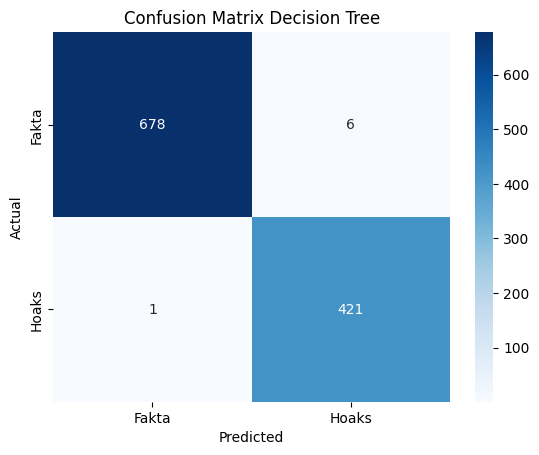

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Fakta','Hoaks'], yticklabels=['Fakta','Hoaks'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Decision Tree")
plt.show()

# TRAIN DATA (SVM)

Average Accuracy: 0.9974
Average Precision: 0.9963
Average Recall: 0.9985
Average F1-Score: 0.9974
SVM model saved as model_svm.pkl


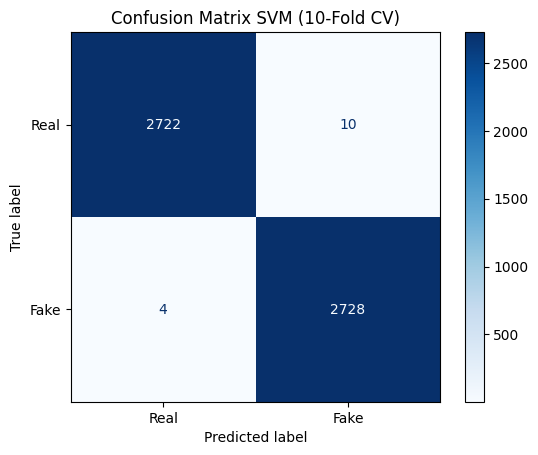

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle
import matplotlib.pyplot as plt

# 1. Define SVM model
svm_model = LinearSVC(random_state=42)

# 2. Cross-validation
cv_results_svm = cross_validate(
    svm_model,
    X_train_res,
    y_train_res,
    cv=kf,
    scoring=scoring_metrics
)

print(f"Average Accuracy: {cv_results_svm['test_accuracy'].mean():.4f}")
print(f"Average Precision: {cv_results_svm['test_precision'].mean():.4f}")
print(f"Average Recall: {cv_results_svm['test_recall'].mean():.4f}")
print(f"Average F1-Score: {cv_results_svm['test_f1'].mean():.4f}")

# 3. Confusion matrix using CV predictions
y_pred_cv_svm = cross_val_predict(
    svm_model,
    X_train_res,
    y_train_res,
    cv=kf
)

cm_cv_svm = confusion_matrix(y_train_res, y_pred_cv_svm)

# 4. Train final model and save
svm_model.fit(X_train_res, y_train_res)
with open("model_svm.pkl", "wb") as f:
    pickle.dump(svm_model, f)

print("SVM model saved as model_svm.pkl")

# 5. Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cv_svm,
    display_labels=['Real', 'Fake']
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix SVM (10-Fold CV)")
plt.show()


## Predict Unseen Data

In [ ]:
y_pred_svm = svm_model.predict(X_test_tfidf)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("\n=== SVM Evaluation ===")
print("Accuracy :", acc_svm)
print("Precision:", prec_svm)
print("Recall   :", rec_svm)
print("F1-Score :", f1_svm)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


=== SVM Evaluation ===
Accuracy : 0.9981916817359855
Precision: 0.9952830188679245
Recall   : 1.0
F1-Score : 0.9976359338061466

Confusion Matrix:
[[682   2]
 [  0 422]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       684
           1       1.00      1.00      1.00       422

    accuracy                           1.00      1106
   macro avg       1.00      1.00      1.00      1106
weighted avg       1.00      1.00      1.00      1106



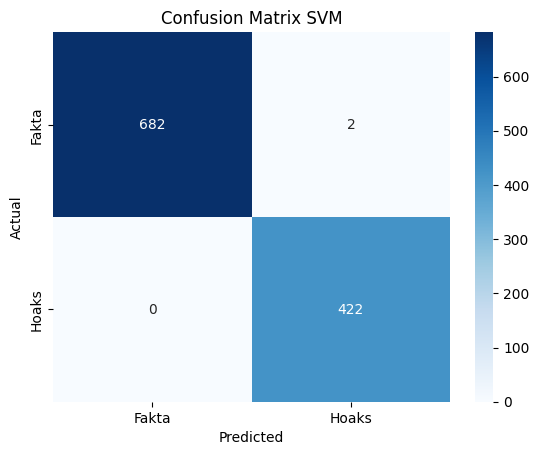

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fakta', 'Hoaks'],
    yticklabels=['Fakta', 'Hoaks']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix SVM")
plt.show()


# PERBANDINGAN HASIL TESTING TIAP MODEL

In [ ]:
metrics_data = {
    'Naive Bayes': {
        'Accuracy': acc_nb,
        'Precision': prec_nb,
        'Recall': rec_nb,
        'F1-Score': f1_nb
    },
    'Logistic Regression': {
        'Accuracy': acc_lg,
        'Precision': prec_lg,
        'Recall': rec_lg,
        'F1-Score': f1_lg
    },
    'Decision Tree': {
        'Accuracy': acc_dt,
        'Precision': prec_dt,
        'Recall': rec_dt,
        'F1-Score': f1_dt
    },
    'SVM': {
        'Accuracy': acc_svm,
        'Precision': prec_svm,
        'Recall': rec_svm,
        'F1-Score': f1_svm
    }
}

metrics_df = pd.DataFrame(metrics_data).T.sort_values(by='F1-Score', ascending=False)
print(metrics_df)


                     Accuracy  Precision    Recall  F1-Score
SVM                  0.998192   0.995283  1.000000  0.997636
Logistic Regression  0.996383   0.995261  0.995261  0.995261
Naive Bayes          0.980108   0.973934  0.973934  0.973934
Decision Tree        0.980108   0.973934  0.973934  0.973934


/tmp/ipython-input-1964470076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_scores, palette='viridis')


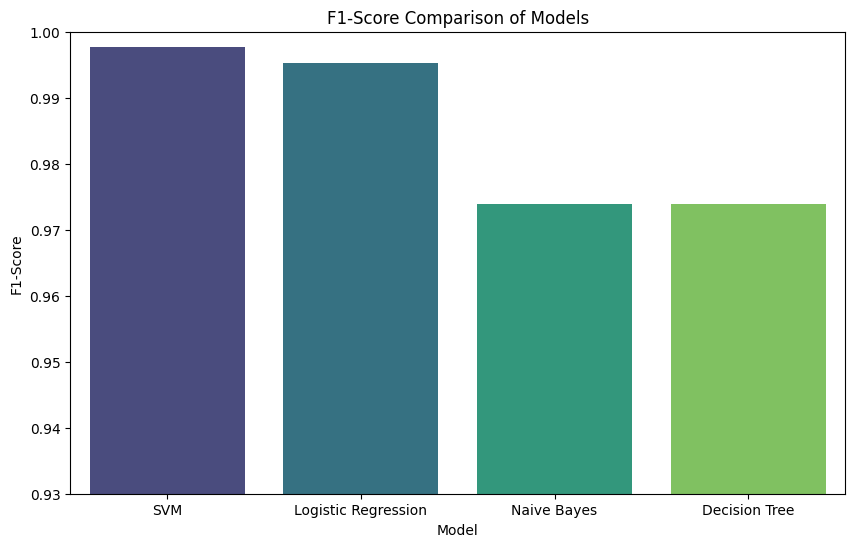

In [ ]:
f1_scores = metrics_df['F1-Score']
models = metrics_df.index

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=f1_scores, palette='viridis')
plt.title('F1-Score Comparison of Models')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.ylim(0.93, 1.0)
plt.show()